In [2]:
pip install uproot awkward matplotlib

📄 Available branches:
  - part_px
  - part_py
  - part_pz
  - part_energy
  - part_deta
  - part_dphi
  - part_d0val
  - part_d0err
  - part_dzval
  - part_dzerr
  - part_charge
  - part_isChargedHadron
  - part_isNeutralHadron
  - part_isPhoton
  - part_isElectron
  - part_isMuon
  - label_QCD
  - label_Hbb
  - label_Hcc
  - label_Hgg
  - label_H4q
  - label_Hqql
  - label_Zqq
  - label_Wqq
  - label_Tbqq
  - label_Tbl
  - jet_pt
  - jet_eta
  - jet_phi
  - jet_energy
  - jet_nparticles
  - jet_sdmass
  - jet_tau1
  - jet_tau2
  - jet_tau3
  - jet_tau4
  - aux_genpart_eta
  - aux_genpart_phi
  - aux_genpart_pid
  - aux_genpart_pt
  - aux_truth_match

✅ Valid variables to load: ['jet_pt', 'jet_eta', 'jet_phi', 'jet_sdmass']


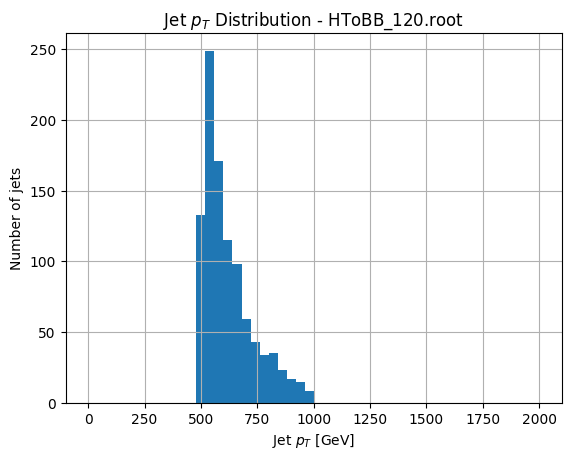

In [10]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt

# Open the ROOT file
file = uproot.open("val_5M/HToBB_120.root")

# Access the TTree named "tree"
tree = file["tree"]

# List all available branches in the tree
branches = tree.keys()
print("📄 Available branches:")
for b in branches:
    print("  -", b)

# Choose the jet-level variables you want to load
desired = ["jet_pt", "jet_eta", "jet_phi", "jet_sdmass"]

# Filter only the variables that are actually present
valid = [var for var in desired if var in branches]
print("\n✅ Valid variables to load:", valid)

# Load up to 1000 entries of the valid branches
arrays = tree.arrays(valid, entry_stop=1000)

# Plot the distribution of jet_pt if it's available
if "jet_pt" in arrays.fields:
    plt.hist(ak.to_numpy(arrays["jet_pt"]), bins=50, range=(0, 2000))
    plt.xlabel("Jet $p_T$ [GeV]")
    plt.ylabel("Number of jets")
    plt.title("Jet $p_T$ Distribution - HToBB_120.root")
    plt.grid(True)
    plt.show()
else:
    print("❌ 'jet_pt' is not available in this file.")


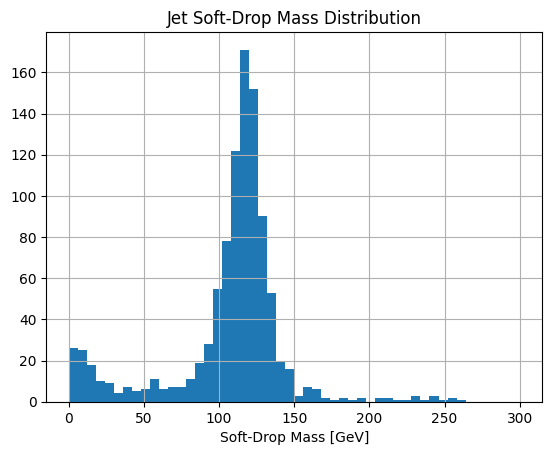

In [11]:
plt.hist(ak.to_numpy(arrays["jet_sdmass"]), bins=50, range=(0, 300))
plt.xlabel("Soft-Drop Mass [GeV]")
plt.title("Jet Soft-Drop Mass Distribution")
plt.grid(True)
plt.show()

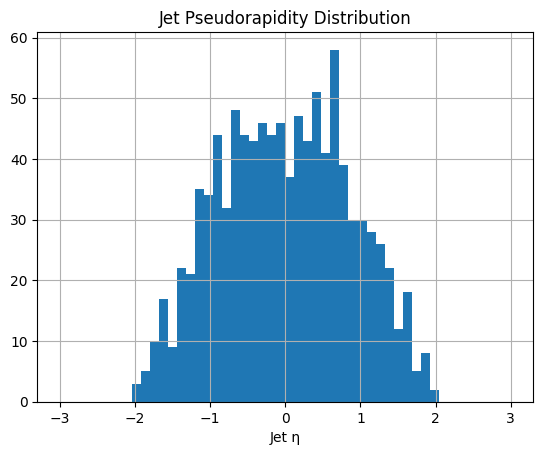

In [12]:
plt.hist(ak.to_numpy(arrays["jet_eta"]), bins=50, range=(-3, 3))
plt.xlabel("Jet η")
plt.title("Jet Pseudorapidity Distribution")
plt.grid(True)
plt.show()


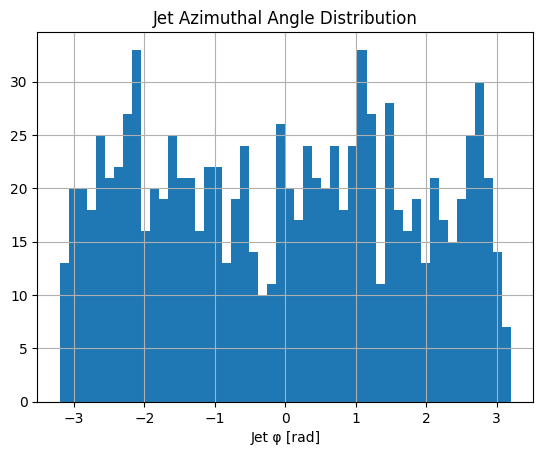

In [13]:
plt.hist(ak.to_numpy(arrays["jet_phi"]), bins=50, range=(-3.2, 3.2))
plt.xlabel("Jet φ [rad]")
plt.title("Jet Azimuthal Angle Distribution")
plt.grid(True)
plt.show()

In [24]:
# Desired jet-level features including N-subjettiness
desired = ["jet_pt", "jet_tau1", "jet_tau2"]

# Filter only the branches that are actually present
valid = [var for var in desired if var in branches]
print("\n✅ Variables to load:", valid)

# Load data
arrays = tree.arrays(valid, entry_stop=1000)



✅ Variables to load: ['jet_pt', 'jet_tau1', 'jet_tau2']


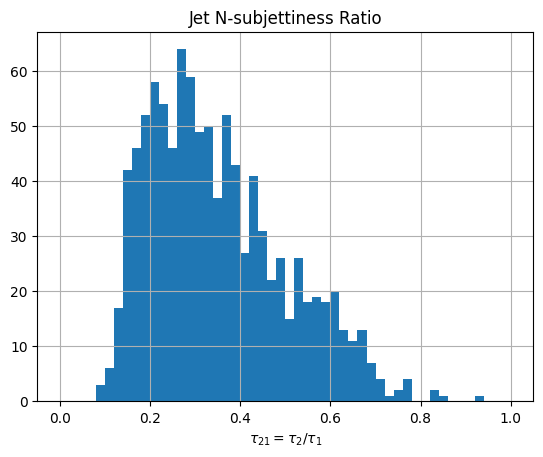

In [25]:
if "jet_tau1" in arrays.fields and "jet_tau2" in arrays.fields:
    tau1 = arrays["jet_tau1"]
    tau2 = arrays["jet_tau2"]
    tau21 = tau2 / tau1

    import matplotlib.pyplot as plt
    import awkward as ak

    plt.hist(ak.to_numpy(tau21), bins=50, range=(0, 1))
    plt.xlabel(r"$\tau_{21} = \tau_2 / \tau_1$")
    plt.title("Jet N-subjettiness Ratio")
    plt.grid(True)
    plt.show()
else:
    print("jet_tau1 or jet_tau2 is not available in this file.")


In [27]:
desired = ["jet_pt", "jet_nparticles"]

# Filter only the valid ones
valid = [var for var in desired if var in branches]
arrays = tree.arrays(valid, entry_stop=1000)


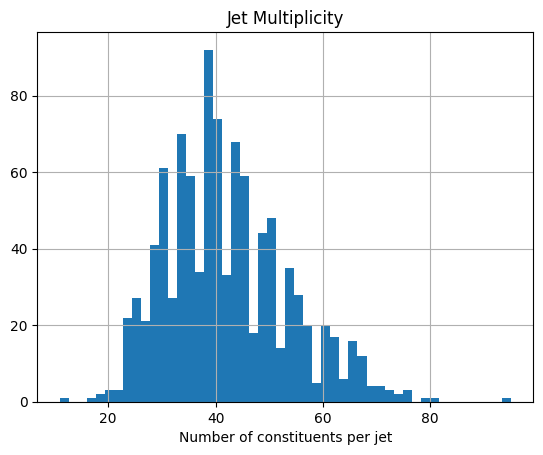

In [28]:
if "jet_nparticles" in arrays.fields:
    plt.hist(ak.to_numpy(arrays["jet_nparticles"]), bins=50)
    plt.xlabel("Number of constituents per jet")
    plt.title("Jet Multiplicity")
    plt.grid(True)
    plt.show()
else:
    print("'jet_nparticles' is not present in this file.")


In [29]:
px = ak.flatten(arrays["part_px"])
py = ak.flatten(arrays["part_py"])

pt = (px**2 + py**2)**0.5

plt.hist(ak.to_numpy(pt), bins=100, range=(0, 200))
plt.xlabel("Constituent $p_T$ [GeV]")
plt.title("Constituent Transverse Momentum")
plt.grid(True)
plt.show()


FieldNotFoundError: no field 'part_px' in record with 2 fields

In [ ]:
desired = ["part_px", "part_py"]

valid = [var for var in desired if var in branches]
arrays = tree.arrays(valid, entry_stop=1000)

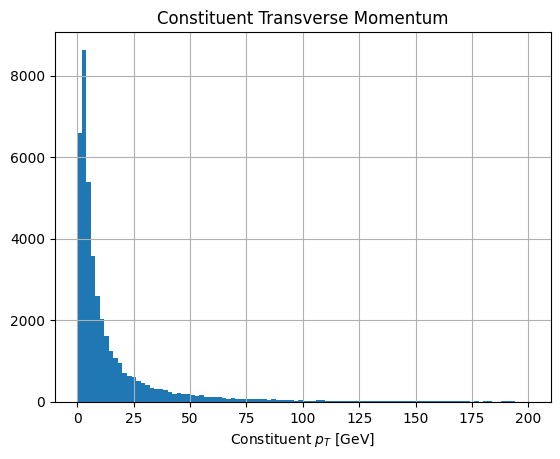

In [ ]:

# Flatten constituent px and py across all jets
px = ak.flatten(arrays["part_px"])
py = ak.flatten(arrays["part_py"])

# Compute transverse momentum
pt = np.sqrt(px**2 + py**2)

# Plot histogram
plt.hist(pt, bins=100, range=(0, 200))
plt.xlabel("Constituent $p_T$ [GeV]")
plt.ylabel("Particle count")
plt.title("Constituent Transverse Momentum Distribution")
plt.grid(True)
plt.show()


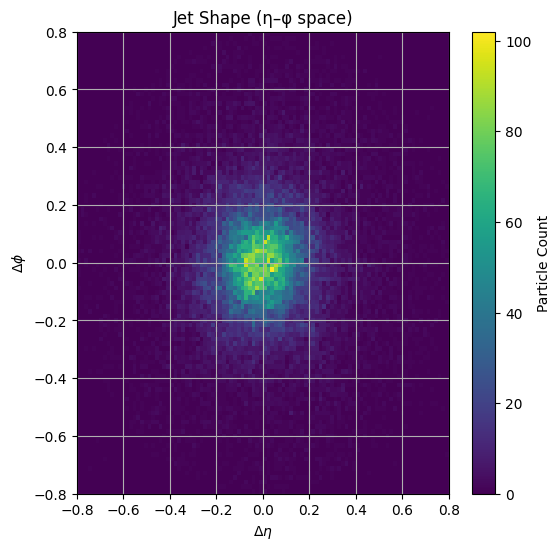

In [35]:
desired = ["part_deta", "part_dphi"]

valid = [var for var in desired if var in branches]
arrays = tree.arrays(valid, entry_stop=1000)



deta = ak.to_numpy(ak.flatten(arrays["part_deta"]))
dphi = ak.to_numpy(ak.flatten(arrays["part_dphi"]))

plt.figure(figsize=(6, 6))
plt.hist2d(deta, dphi, bins=100, range=[[-0.8, 0.8], [-0.8, 0.8]], cmap="viridis")
plt.xlabel(r"$\Delta \eta$")
plt.ylabel(r"$\Delta \phi$")
plt.title("Jet Shape (η–φ space)")
plt.colorbar(label="Particle Count")
plt.grid(True)
plt.show()


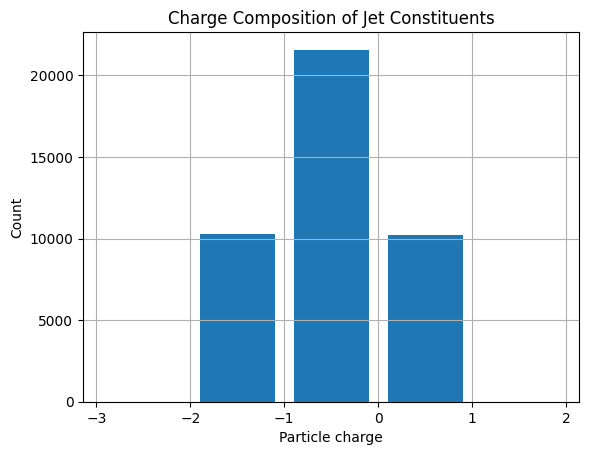

In [36]:
desired = ["part_charge"]  # Add this field to load
valid = [var for var in desired if var in branches]
arrays = tree.arrays(valid, entry_stop=1000)


if "part_charge" in arrays.fields:
    charge = ak.to_numpy(ak.flatten(arrays["part_charge"]))
    plt.hist(charge, bins=np.arange(-2.5, 3.5, 1), align="left", rwidth=0.8)
    plt.xlabel("Particle charge")
    plt.ylabel("Count")
    plt.title("Charge Composition of Jet Constituents")
    plt.grid(True)
    plt.show()
else:
    print("❌ 'part_charge' not found in the loaded data.")


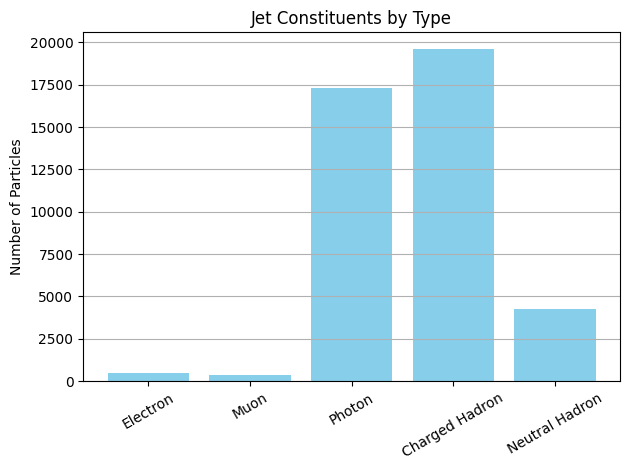

In [37]:
desired = [
    "part_isElectron", "part_isMuon", "part_isPhoton",
    "part_isChargedHadron", "part_isNeutralHadron"
]
valid = [var for var in desired if var in branches]
arrays = tree.arrays(valid, entry_stop=1000)

if all(field in arrays.fields for field in desired):
    # Flatten all types
    electron = ak.to_numpy(ak.flatten(arrays["part_isElectron"]))
    muon = ak.to_numpy(ak.flatten(arrays["part_isMuon"]))
    photon = ak.to_numpy(ak.flatten(arrays["part_isPhoton"]))
    charged_hadron = ak.to_numpy(ak.flatten(arrays["part_isChargedHadron"]))
    neutral_hadron = ak.to_numpy(ak.flatten(arrays["part_isNeutralHadron"]))

    # Count types
    counts = [
        electron.sum(),
        muon.sum(),
        photon.sum(),
        charged_hadron.sum(),
        neutral_hadron.sum()
    ]

    labels = ["Electron", "Muon", "Photon", "Charged Hadron", "Neutral Hadron"]

    # Plot
    plt.bar(labels, counts, color="skyblue")
    plt.xticks(rotation=30)
    plt.ylabel("Number of Particles")
    plt.title("Jet Constituents by Type")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("❌ One or more particle ID fields are missing.")


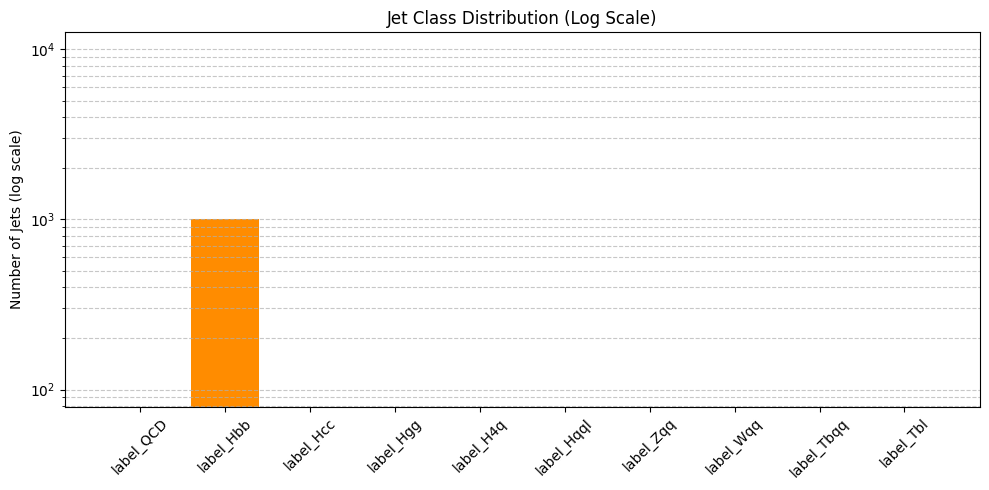

In [39]:

# Define all label fields (jet classes)
label_fields = [
    "label_QCD", "label_Hbb", "label_Hcc", "label_Hgg", "label_H4q",
    "label_Hqql", "label_Zqq", "label_Wqq", "label_Tbqq", "label_Tbl"
]

# Filter only available fields
valid = [field for field in label_fields if field in branches]
arrays = tree.arrays(valid, entry_stop=1000)  # You can remove entry_stop to get all data

# Count jets per class
class_counts = [ak.to_numpy(arrays[label]).sum() for label in valid]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(valid, class_counts, color="darkorange")
plt.yscale("log")  # Set y-axis to log scale
plt.xticks(rotation=45)
plt.ylabel("Number of Jets (log scale)")
plt.title("Jet Class Distribution (Log Scale)")
plt.grid(axis="y", which="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


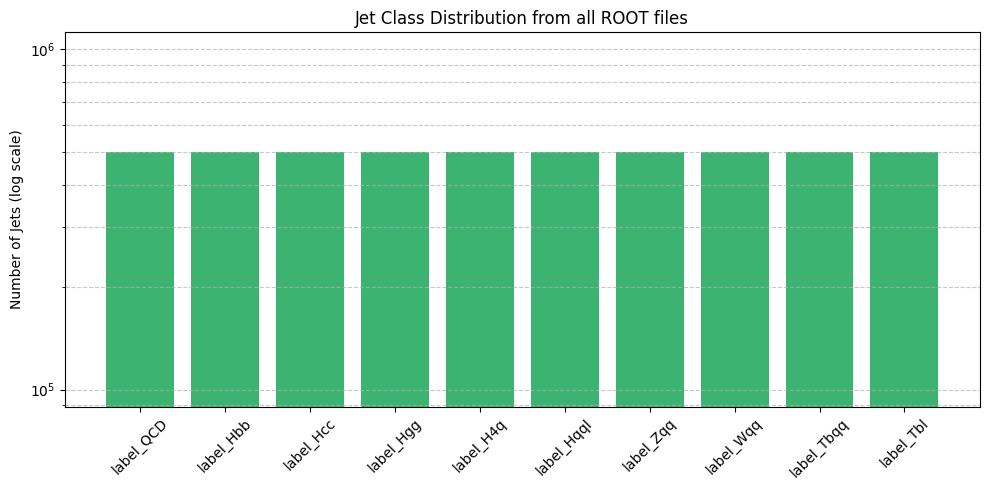

In [41]:
import uproot
import awkward as ak
import os

# Set path to your val_5M dataset
path = "val_5M"
label_fields = [
    "label_QCD", "label_Hbb", "label_Hcc", "label_Hgg", "label_H4q",
    "label_Hqql", "label_Zqq", "label_Wqq", "label_Tbqq", "label_Tbl"
]

total_counts = dict.fromkeys(label_fields, 0)

for fname in os.listdir(path):
    if not fname.endswith(".root"):
        continue
    with uproot.open(os.path.join(path, fname)) as file:
        tree = file["tree"]
        available = [label for label in label_fields if label in tree.keys()]
        arrays = tree.arrays(available)
        for label in available:
            total_counts[label] += ak.to_numpy(arrays[label]).sum()

# Now plot
import matplotlib.pyplot as plt

labels = list(total_counts.keys())
values = list(total_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="mediumseagreen")
plt.yscale("log")
plt.xticks(rotation=45)
plt.ylabel("Number of Jets (log scale)")
plt.title("Jet Class Distribution from all ROOT files")
plt.grid(axis="y", which="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Constituent Δη vs Δφ')

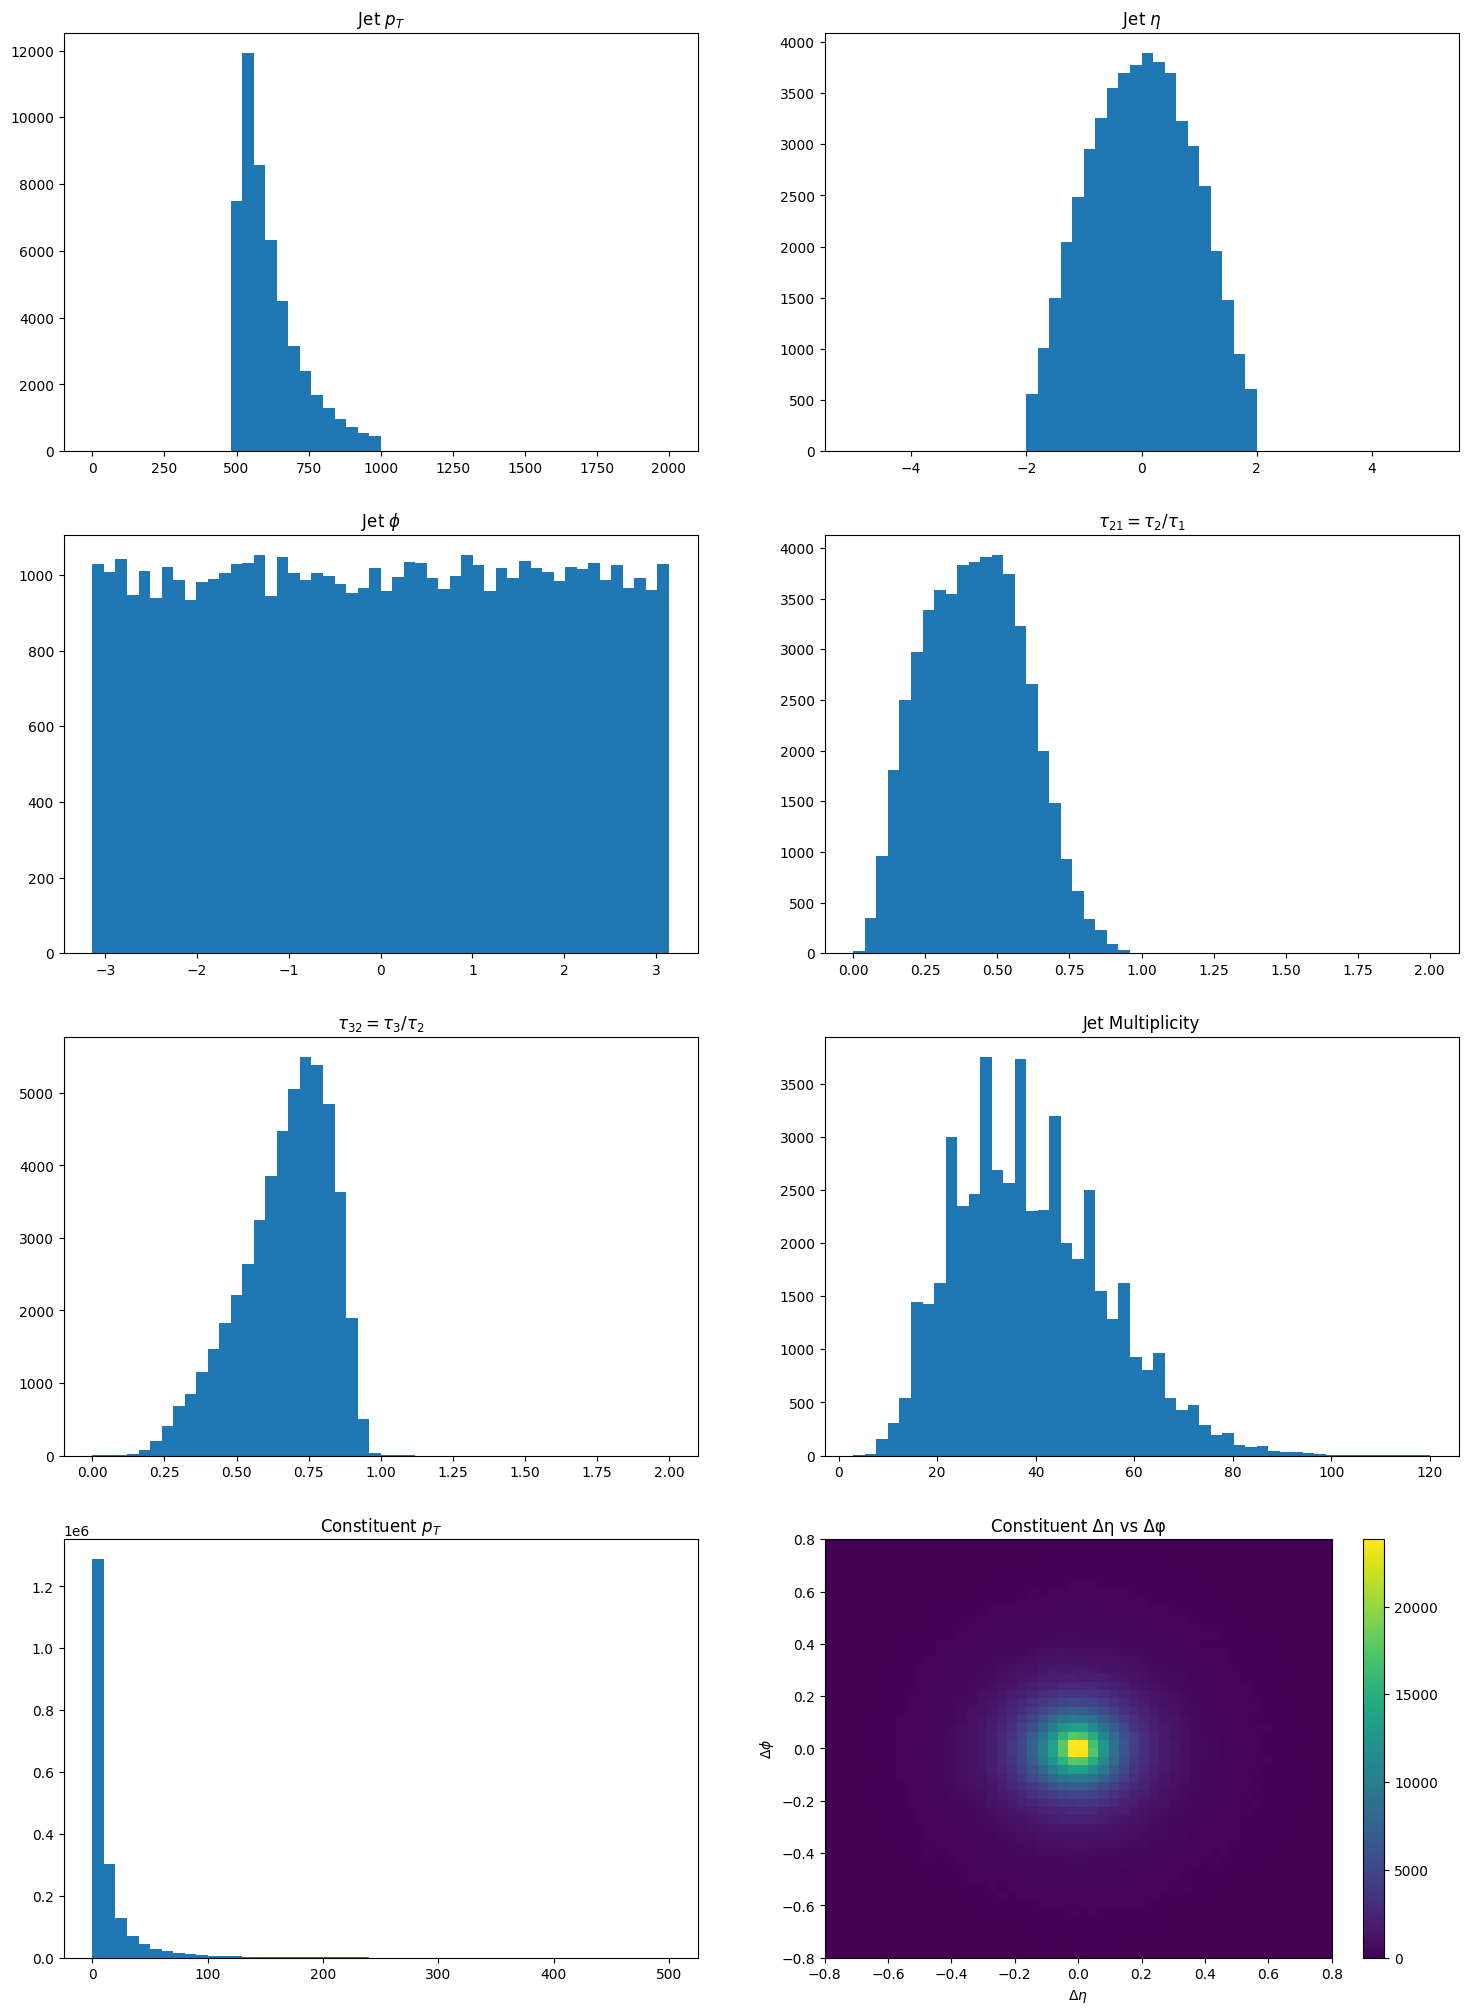

In [43]:
import os
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Directory where your ROOT files are stored
directory_path = "val_5M"

# Accumulators for all variables
jet_pt, jet_eta, jet_phi = [], [], []
tau21, tau32, jet_nparticles = [], [], []
part_px, part_py = [], []
part_deta, part_dphi = [], []

# Helper for division
def safe_divide(num, den):
    return np.where(den != 0, num / den, 0)

# Loop through all .root files
for filename in os.listdir(directory_path):
    if filename.endswith(".root"):
        file_path = os.path.join(directory_path, filename)
        try:
            with uproot.open(file_path) as file:
                tree = file["tree"]
                arrays = tree.arrays([
                    "jet_pt", "jet_eta", "jet_phi",
                    "jet_tau1", "jet_tau2", "jet_tau3",
                    "jet_nparticles", "part_px", "part_py",
                    "part_deta", "part_dphi"
                ], entry_stop=1000)

                jet_pt.append(arrays["jet_pt"])
                jet_eta.append(arrays["jet_eta"])
                jet_phi.append(arrays["jet_phi"])
                tau21.append(safe_divide(arrays["jet_tau2"], arrays["jet_tau1"]))
                tau32.append(safe_divide(arrays["jet_tau3"], arrays["jet_tau2"]))
                jet_nparticles.append(arrays["jet_nparticles"])
                part_px.append(ak.flatten(arrays["part_px"]))
                part_py.append(ak.flatten(arrays["part_py"]))
                part_deta.append(ak.flatten(arrays["part_deta"]))
                part_dphi.append(ak.flatten(arrays["part_dphi"]))
        except Exception as e:
            print(f"Error in {filename}: {e}")

# Merge all arrays
jet_pt = ak.concatenate(jet_pt)
jet_eta = ak.concatenate(jet_eta)
jet_phi = ak.concatenate(jet_phi)
tau21 = ak.concatenate(tau21)
tau32 = ak.concatenate(tau32)
jet_nparticles = ak.concatenate(jet_nparticles)
part_px = ak.concatenate(part_px)
part_py = ak.concatenate(part_py)
part_deta = ak.concatenate(part_deta)
part_dphi = ak.concatenate(part_dphi)
part_pt = np.sqrt(part_px**2 + part_py**2)

# Plot
plt.figure(figsize=(18, 25))

# 1. Jet pt
plt.subplot(4, 2, 1)
plt.hist(jet_pt, bins=50, range=(0, 2000))
plt.title("Jet $p_T$")

# 2. Jet eta
plt.subplot(4, 2, 2)
plt.hist(jet_eta, bins=50, range=(-5, 5))
plt.title("Jet $\eta$")

# 3. Jet phi
plt.subplot(4, 2, 3)
plt.hist(jet_phi, bins=50, range=(-np.pi, np.pi))
plt.title("Jet $\phi$")

# 4. tau21
plt.subplot(4, 2, 4)
plt.hist(tau21, bins=50, range=(0, 2))
plt.title(r"$\tau_{21} = \tau_2 / \tau_1$")

# 5. tau32
plt.subplot(4, 2, 5)
plt.hist(tau32, bins=50, range=(0, 2))
plt.title(r"$\tau_{32} = \tau_3 / \tau_2$")

# 6. Multiplicity
plt.subplot(4, 2, 6)
plt.hist(jet_nparticles, bins=50)
plt.title("Jet Multiplicity")

# 7. Constituent pt
plt.subplot(4, 2, 7)
plt.hist(part_pt, bins=50, range=(0, 500))
plt.title("Constituent $p_T$")

# 8. Δη vs Δφ
# 8. Δη vs Δφ
plt.subplot(4, 2, 8)
plt.hist2d(
    ak.to_numpy(part_deta),
    ak.to_numpy(part_dphi),
    bins=50,
    range=[[-0.8, 0.8], [-0.8, 0.8]],
    cmap="viridis"
)
plt.colorbar()
plt.xlabel(r"$\Delta\eta$")
plt.ylabel(r"$\Delta\phi$")
plt.title("Constituent Δη vs Δφ")



In [44]:
pip install awkward


Note: you may need to restart the kernel to use updated packages.


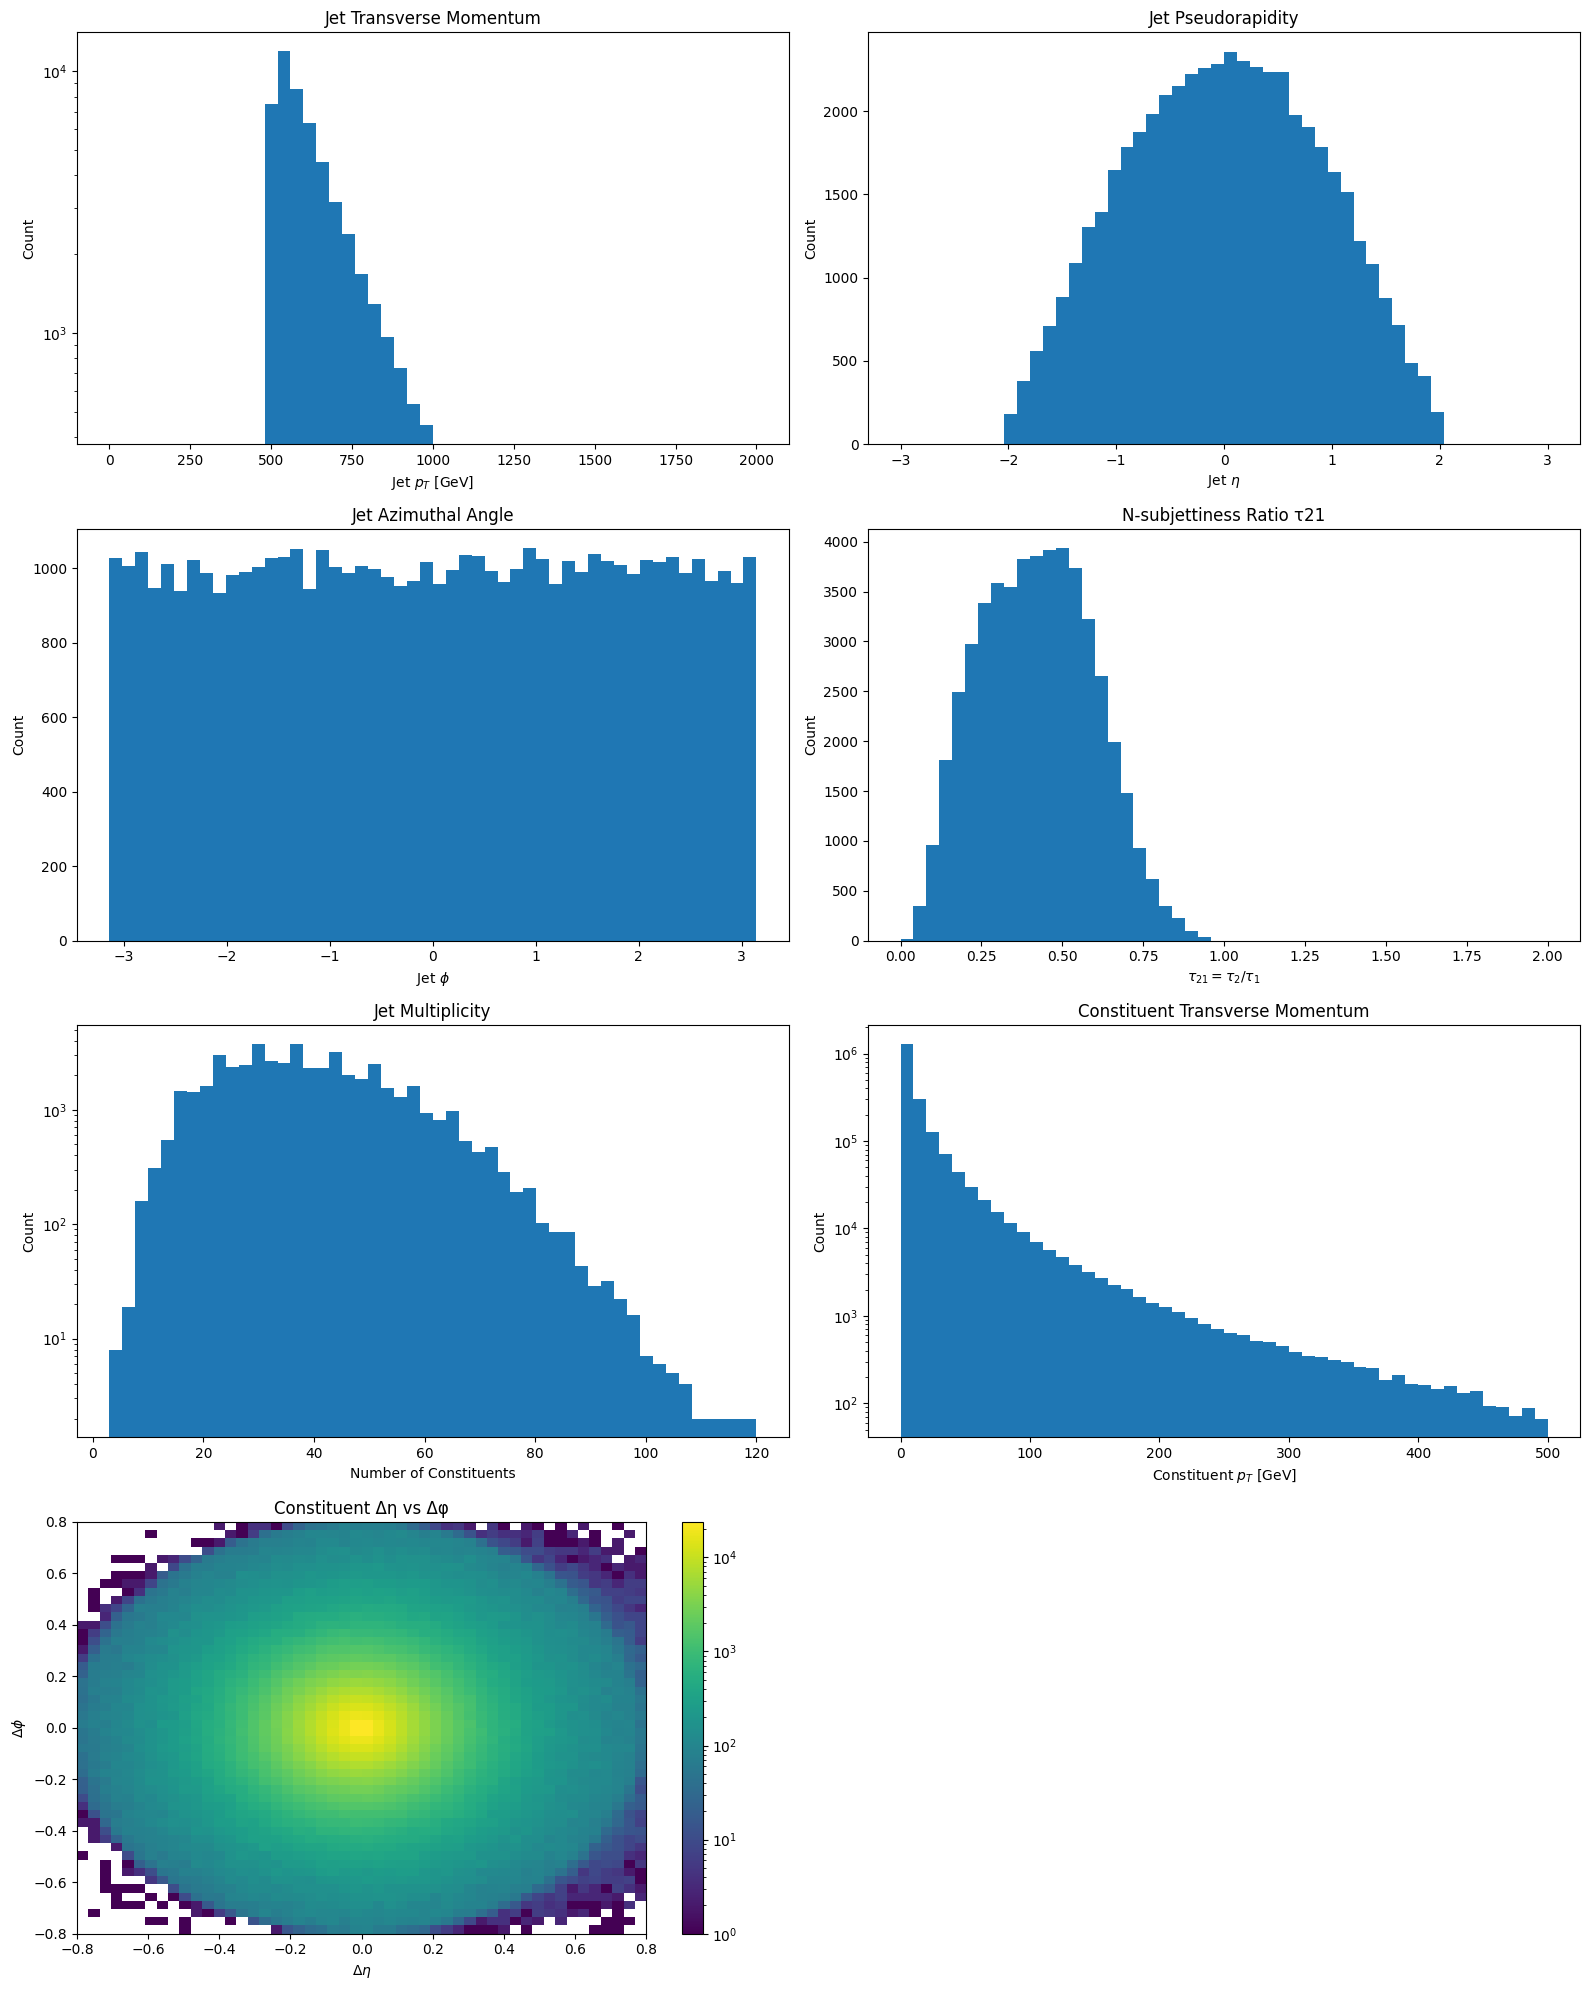

In [46]:
import os
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Path to the directory containing your ROOT files
directory_path = "val_5M"

# Initialize accumulators
jet_pt, jet_eta, jet_phi = [], [], []
tau21, jet_nparticles = [], []
part_px, part_py = [], []
part_deta, part_dphi = [], []

# Safe division
def safe_divide(num, den):
    return np.where(den != 0, num / den, 0)

# Loop through all ROOT files
for filename in os.listdir(directory_path):
    if filename.endswith(".root"):
        file_path = os.path.join(directory_path, filename)
        try:
            with uproot.open(file_path) as file:
                tree = file["tree"]
                arrays = tree.arrays([
                    "jet_pt", "jet_eta", "jet_phi",
                    "jet_tau1", "jet_tau2",
                    "jet_nparticles", "part_px", "part_py",
                    "part_deta", "part_dphi"
                ], entry_stop=1000)

                jet_pt.append(arrays["jet_pt"])
                jet_eta.append(arrays["jet_eta"])
                jet_phi.append(arrays["jet_phi"])
                tau21.append(safe_divide(arrays["jet_tau2"], arrays["jet_tau1"]))
                jet_nparticles.append(arrays["jet_nparticles"])
                part_px.append(ak.flatten(arrays["part_px"]))
                part_py.append(ak.flatten(arrays["part_py"]))
                part_deta.append(ak.flatten(arrays["part_deta"]))
                part_dphi.append(ak.flatten(arrays["part_dphi"]))
        except Exception as e:
            print(f"Error in {filename}: {e}")

# Merge all arrays
jet_pt = ak.to_numpy(ak.concatenate(jet_pt))
jet_eta = ak.to_numpy(ak.concatenate(jet_eta))
jet_phi = ak.to_numpy(ak.concatenate(jet_phi))
tau21 = ak.to_numpy(ak.concatenate(tau21))
jet_nparticles = ak.to_numpy(ak.concatenate(jet_nparticles))
part_px = ak.to_numpy(ak.concatenate(part_px))
part_py = ak.to_numpy(ak.concatenate(part_py))
part_deta = ak.to_numpy(ak.concatenate(part_deta))
part_dphi = ak.to_numpy(ak.concatenate(part_dphi))
part_pt = np.sqrt(part_px**2 + part_py**2)

# Plotting
fig, axs = plt.subplots(4, 2, figsize=(16, 20))
axs = axs.ravel()

# 1. Jet pT
axs[0].hist(jet_pt, bins=50, range=(0, 2000), log=True)
axs[0].set_xlabel("Jet $p_T$ [GeV]")
axs[0].set_ylabel("Count")
axs[0].set_title("Jet Transverse Momentum")

# 2. Jet η
axs[1].hist(jet_eta, bins=50, range=(-3, 3))
axs[1].set_xlabel("Jet $\eta$")
axs[1].set_ylabel("Count")
axs[1].set_title("Jet Pseudorapidity")

# 3. Jet φ
axs[2].hist(jet_phi, bins=50, range=(-np.pi, np.pi))
axs[2].set_xlabel("Jet $\phi$")
axs[2].set_ylabel("Count")
axs[2].set_title("Jet Azimuthal Angle")

# 4. τ21
axs[3].hist(tau21, bins=50, range=(0, 2))
axs[3].set_xlabel(r"$\tau_{21} = \tau_2 / \tau_1$")
axs[3].set_ylabel("Count")
axs[3].set_title("N-subjettiness Ratio τ21")

# 5. Jet Multiplicity
axs[4].hist(jet_nparticles, bins=50, log=True)
axs[4].set_xlabel("Number of Constituents")
axs[4].set_ylabel("Count")
axs[4].set_title("Jet Multiplicity")

# 6. Constituent pT
axs[5].hist(part_pt, bins=50, range=(0, 500), log=True)
axs[5].set_xlabel("Constituent $p_T$ [GeV]")
axs[5].set_ylabel("Count")
axs[5].set_title("Constituent Transverse Momentum")

# 7. Δη vs Δφ (2D histogram, log scale)
h = axs[6].hist2d(part_deta, part_dphi, bins=50,
                  range=[[-0.8, 0.8], [-0.8, 0.8]],
                  cmap="viridis", norm="log")
plt.colorbar(h[3], ax=axs[6])
axs[6].set_xlabel(r"$\Delta\eta$")
axs[6].set_ylabel(r"$\Delta\phi$")
axs[6].set_title("Constituent Δη vs Δφ")

# 8. Empty slot (optional additional plot)
axs[7].axis('off')

plt.tight_layout()
plt.show()


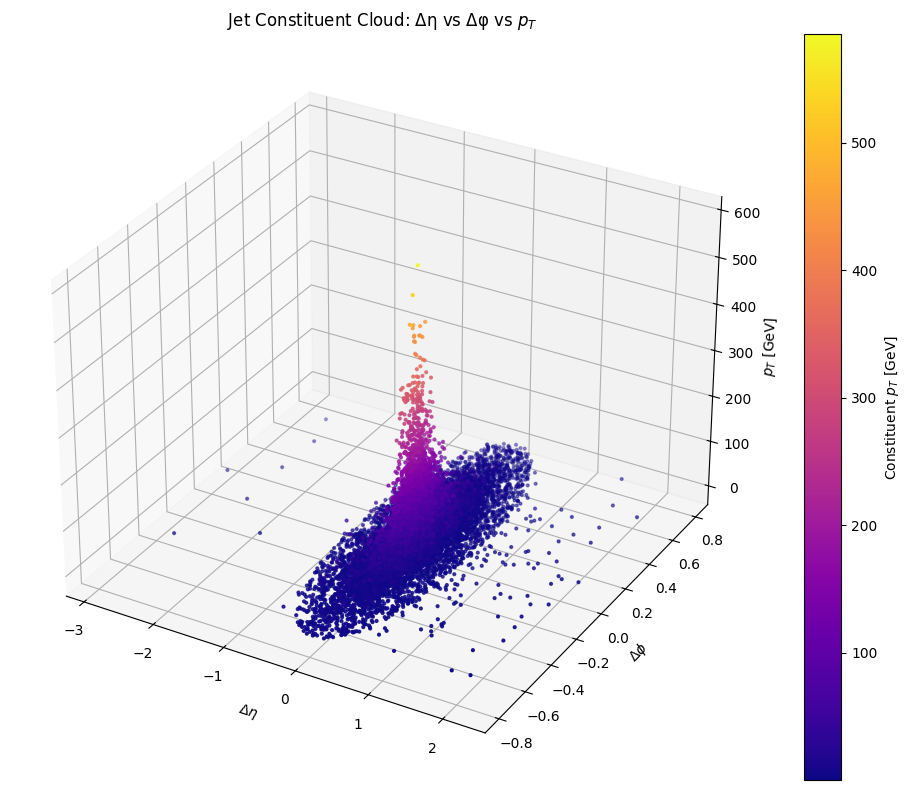

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# ✅ Correct field check
if all(field in arrays.fields for field in ["part_deta", "part_dphi", "part_px", "part_py"]):
    deta = ak.to_numpy(ak.flatten(arrays["part_deta"]))
    dphi = ak.to_numpy(ak.flatten(arrays["part_dphi"]))
    px = ak.to_numpy(ak.flatten(arrays["part_px"]))
    py = ak.to_numpy(ak.flatten(arrays["part_py"]))
    pt = np.sqrt(px**2 + py**2)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    p = ax.scatter(deta, dphi, pt, c=pt, cmap="plasma", s=4)
    fig.colorbar(p, ax=ax, label=r"Constituent $p_T$ [GeV]")

    ax.set_xlabel(r"$\Delta\eta$")
    ax.set_ylabel(r"$\Delta\phi$")
    ax.set_zlabel(r"$p_T$ [GeV]")
    ax.set_title("Jet Constituent Cloud: Δη vs Δφ vs $p_T$")
    plt.tight_layout()
    plt.show()
else:
    print("One or more required fields are missing from the arrays.")


In [57]:
import uproot
import awkward as ak
import os

# Directory containing ROOT files
folder = "val_5M"
files = [f for f in os.listdir(folder) if f.endswith(".root")]

# Fields we want to load
fields_to_load = ["part_px", "part_py", "part_pz"]

all_arrays = []

for fname in files:
    with uproot.open(os.path.join(folder, fname))["tree"] as tree:
        arrays = tree.arrays(fields_to_load)
        all_arrays.append(arrays)

arrays = ak.concatenate(all_arrays)


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Flatten the constituent arrays
px = ak.to_numpy(ak.flatten(arrays["part_px"]))
py = ak.to_numpy(ak.flatten(arrays["part_py"]))
pz = ak.to_numpy(ak.flatten(arrays["part_pz"]))
pt = np.sqrt(px**2 + py**2)

# 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(px, py, pz, c=np.log10(pt + 1e-3), cmap='plasma', s=0.3, alpha=0.4)

ax.set_xlabel('pₓ [GeV]')
ax.set_ylabel('pᵧ [GeV]')
ax.set_zlabel('p_z [GeV]')
ax.set_title("3D Jet Constituent Momentum (Colored by log($p_T$))")

fig.colorbar(sc, label='log($p_T$) [GeV]')
plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>